# 07. Analyse Comparative des Modèles

**Objectif** : Analyser en détail les différences entre tous les modèles de machine learning

**Pour les analystes** : Ce notebook compare toutes les approches pour identifier le meilleur modèle

In [1]:
# Importer les bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
from scipy import stats
import time

warnings.filterwarnings('ignore')

# Modèles ML
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb

# Évaluation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# Configuration du style
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')
    except:
        plt.style.use('default')

# Configuration des graphiques
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("📚 Bibliothèques importées avec succès !")
print("🔍 Analyse Comparative des Modèles prête")

📚 Bibliothèques importées avec succès !
🔍 Analyse Comparative des Modèles prête


In [2]:
# Charger et préparer les données
print("=== CHARGEMENT DES DONNÉES ===")

# Charger les données
df = pd.read_csv("../data/real_estate_processed.csv")
print(f"Données originales: {df.shape}")

# Nettoyage
df_clean = df[(df['price'] >= 50) & (df['price'] <= 10000000)].copy()
print(f"Données après nettoyage: {df_clean.shape}")
print(f"Supprimées: {len(df) - len(df_clean)} annonces")

df = df_clean

print(f"\n📊 STATISTIQUES DES PRIX:")
print(f"   Moyenne: {df['price'].mean():,.0f} DT")
print(f"   Médiane: {df['price'].median():,.0f} DT")
print(f"   Écart-type: {df['price'].std():,.0f} DT")
print(f"   Min: {df['price'].min():,.0f} DT")
print(f"   Max: {df['price'].max():,.0f} DT")
print(f"   Skewness: {stats.skew(df['price']):.4f}")

# Feature Engineering unifié
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
X_base = df[numeric_columns].drop('price', axis=1)
y = df['price']

print(f"\nColonnes disponibles: {X_base.columns.tolist()}")

# Features unifiées pour tous les modèles
X = X_base.copy()

# Features d'interaction
X['category_transaction_interaction'] = X['category'] * X['type_transaction']
X['category_month_interaction'] = X['category'] * X['post_month']
X['transaction_month_interaction'] = X['type_transaction'] * X['post_month']
X['category_year_interaction'] = X['category'] * X['post_year']

# Features polynomiales (uniquement pour les colonnes qui existent)
X['category_squared'] = X['category'] ** 2
X['type_transaction_squared'] = X['type_transaction'] ** 2
X['month_squared'] = X['post_month'] ** 2
X['year_squared'] = X['post_year'] ** 2

# Ajouter rooms_squared seulement si la colonne rooms existe
if 'rooms' in X.columns:
    X['rooms_squared'] = X['rooms'] ** 2

# Features de ratio
X['category_per_month'] = X['category'] / (X['post_month'] + 1)
X['transaction_per_year'] = X['type_transaction'] / (X['post_year'] - 2024 + 1)

# Ajouter rooms_per_category seulement si rooms existe
if 'rooms' in X.columns:
    X['rooms_per_category'] = X['rooms'] / (X['category'] + 1)

# Features temporelles
X['quarter'] = ((X['post_month'] - 1) // 3) + 1
X['is_summer'] = (X['post_month'].isin([6, 7, 8])).astype(int)
X['is_winter'] = (X['post_month'].isin([12, 1, 2])).astype(int)
X['is_spring'] = (X['post_month'].isin([3, 4, 5])).astype(int)
X['is_autumn'] = (X['post_month'].isin([9, 10, 11])).astype(int)

# Target encoding
price_by_category = df.groupby('category')['price'].mean()
price_by_transaction = df.groupby('type_transaction')['price'].mean()
price_by_month = df.groupby('post_month')['price'].mean()
price_by_year = df.groupby('post_year')['price'].mean()

X['category_price_mean'] = X['category'].map(price_by_category)
X['transaction_price_mean'] = X['type_transaction'].map(price_by_transaction)
X['month_price_mean'] = X['post_month'].map(price_by_month)
X['year_price_mean'] = X['post_year'].map(price_by_year)

# Ajouter rooms_price_mean seulement si rooms existe
if 'rooms' in X.columns:
    price_by_rooms = df.groupby('rooms')['price'].mean()
    X['rooms_price_mean'] = X['rooms'].map(price_by_rooms)

# Features logarithmiques (uniquement pour les colonnes qui existent)
X['log_category'] = np.log1p(X['category'])
X['log_month'] = np.log1p(X['post_month'])
X['log_year_diff'] = np.log1p(X['post_year'] - 2024)

# Ajouter log_rooms et log_location seulement si ces colonnes existent
if 'rooms' in X.columns:
    X['log_rooms'] = np.log1p(X['rooms'])
if 'location' in X.columns:
    X['log_location'] = np.log1p(X['location'])

# Features de différence
X['category_minus_transaction'] = X['category'] - X['type_transaction']
X['month_minus_year'] = X['post_month'] - (X['post_year'] - 2024)

# Ajouter rooms_minus_category seulement si rooms existe
if 'rooms' in X.columns:
    X['rooms_minus_category'] = X['rooms'] - X['category']

# Remplir les valeurs NaN
X = X.fillna(0)

print(f"\n🔧 FEATURES CRÉÉES: {X_base.shape[1]} -> {X.shape[1]} (+{X.shape[1] - X_base.shape[1]} nouvelles)")

# Transformation de la target
y_log = np.log1p(y)

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)

print(f"\n📊 DIVISION DES DONNÉES:")
print(f"   Entraînement: {X_train.shape[0]} annonces")
print(f"   Test: {X_test.shape[0]} annonces")
print(f"   Features: {X.shape[1]}")

# Normalisation (nécessaire pour KNN et utile pour d'autres)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Données préparées et normalisées")

=== CHARGEMENT DES DONNÉES ===
Données originales: (5653, 12)
Données après nettoyage: (5601, 12)
Supprimées: 52 annonces

📊 STATISTIQUES DES PRIX:
   Moyenne: 176,410 DT
   Médiane: 3,500 DT
   Écart-type: 300,082 DT
   Min: 55 DT
   Max: 6,300,000 DT
   Skewness: 4.8640

Colonnes disponibles: ['category', 'type_transaction', 'post_month', 'post_year']

🔧 FEATURES CRÉÉES: 4 -> 28 (+24 nouvelles)

📊 DIVISION DES DONNÉES:
   Entraînement: 4480 annonces
   Test: 1121 annonces
   Features: 28

✅ Données préparées et normalisées


In [3]:
# Définition de tous les modèles
print("=== DÉFINITION DES MODÈLES ===")

# Configuration des modèles avec paramètres optimisés
models_config = {
    'Linear Regression': {
        'model': LinearRegression(),
        'use_scaled': False,
        'color': 'blue',
        'description': 'Modèle linéaire simple'
    },
    'Random Forest': {
        'model': RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ),
        'use_scaled': False,
        'color': 'green',
        'description': 'Forêt d\'arbres de décision'
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            subsample=1.0,
            random_state=42
        ),
        'use_scaled': False,
        'color': 'orange',
        'description': 'Boosting de gradient'
    },
    'XGBoost': {
        'model': xgb.XGBRegressor(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            objective='reg:squarederror'
        ),
        'use_scaled': False,
        'color': 'red',
        'description': 'Extreme Gradient Boosting'
    },
    'KNN': {
        'model': KNeighborsRegressor(
            n_neighbors=5,
            weights='distance',
            algorithm='auto',
            metric='euclidean'
        ),
        'use_scaled': True,
        'color': 'purple',
        'description': 'K plus proches voisins'
    }
}

print(f"🤖 {len(models_config)} modèles configurés:")
for name, config in models_config.items():
    print(f"   {name:20s}: {config['description']}")

print(f"\n✅ Configuration terminée")

=== DÉFINITION DES MODÈLES ===
🤖 5 modèles configurés:
   Linear Regression   : Modèle linéaire simple
   Random Forest       : Forêt d'arbres de décision
   Gradient Boosting   : Boosting de gradient
   XGBoost             : Extreme Gradient Boosting
   KNN                 : K plus proches voisins

✅ Configuration terminée


In [4]:
# Entraînement et évaluation de tous les modèles
print("=== ENTRAÎNEMENT ET ÉVALUATION ===")

results = []
predictions_dict = {}
training_times = {}

for model_name, config in models_config.items():
    print(f"\n🤖 {model_name}:")
    
    # Choisir les données (scaled ou non)
    if config['use_scaled']:
        X_train_data = X_train_scaled
        X_test_data = X_test_scaled
    else:
        X_train_data = X_train
        X_test_data = X_test
    
    # Entraîner le modèle
    start_time = time.time()
    model = config['model']
    model.fit(X_train_data, y_train)
    training_time = time.time() - start_time
    
    # Prédictions
    y_train_pred = model.predict(X_train_data)
    y_test_pred = model.predict(X_test_data)
    
    # Conversion à l'échelle originale
    y_train_pred_orig = np.expm1(y_train_pred)
    y_test_pred_orig = np.expm1(y_test_pred)
    
    # Calculer les métriques
    train_r2 = r2_score(y_train_orig, y_train_pred_orig)
    test_r2 = r2_score(y_test_orig, y_test_pred_orig)
    train_rmse = np.sqrt(mean_squared_error(y_train_orig, y_train_pred_orig))
    test_rmse = np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig))
    train_mae = mean_absolute_error(y_train_orig, y_train_pred_orig)
    test_mae = mean_absolute_error(y_test_orig, y_test_pred_orig)
    train_mse = mean_squared_error(y_train_orig, y_train_pred_orig)
    test_mse = mean_squared_error(y_test_orig, y_test_pred_orig)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_data, y_train, cv=5, scoring='r2')
    
    # Stocker les résultats
    result = {
        'Model': model_name,
        'R² Train': train_r2,
        'R² Test': test_r2,
        'RMSE Train': train_rmse,
        'RMSE Test': test_rmse,
        'MAE Train': train_mae,
        'MAE Test': test_mae,
        'MSE Train': train_mse,
        'MSE Test': test_mse,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Training Time': training_time,
        'Color': config['color'],
        'Description': config['description']
    }
    
    results.append(result)
    predictions_dict[model_name] = y_test_pred_orig
    training_times[model_name] = training_time
    
    print(f"   R² Test: {test_r2:.4f}")
    print(f"   RMSE Test: {test_rmse:,.0f} DT")
    print(f"   MAE Test: {test_mae:,.0f} DT")
    print(f"   CV Mean: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"   Temps: {training_time:.2f}s")

# Créer un DataFrame avec tous les résultats
results_df = pd.DataFrame(results)

print(f"\n✅ Tous les modèles entraînés et évalués")
print(f"📊 {len(results_df)} modèles analysés")

=== ENTRAÎNEMENT ET ÉVALUATION ===

🤖 Linear Regression:
   R² Test: 0.4708
   RMSE Test: 197,432 DT
   MAE Test: 80,337 DT
   CV Mean: 0.8895 (±0.0170)
   Temps: 0.05s

🤖 Random Forest:
   R² Test: 0.4604
   RMSE Test: 199,358 DT
   MAE Test: 81,023 DT
   CV Mean: 0.8883 (±0.0171)
   Temps: 0.29s

🤖 Gradient Boosting:
   R² Test: 0.4656
   RMSE Test: 198,396 DT
   MAE Test: 80,448 DT
   CV Mean: 0.8893 (±0.0169)
   Temps: 0.80s

🤖 XGBoost:
   R² Test: 0.4603
   RMSE Test: 199,371 DT
   MAE Test: 80,904 DT
   CV Mean: 0.8885 (±0.0170)
   Temps: 0.30s

🤖 KNN:
   R² Test: 0.2064
   RMSE Test: 241,769 DT
   MAE Test: 99,874 DT
   CV Mean: 0.8420 (±0.0130)
   Temps: 0.00s

✅ Tous les modèles entraînés et évalués
📊 5 modèles analysés


In [5]:
# Tableau comparatif détaillé
print("=== TABLEAU COMPARATIF DÉTAILLÉ ===")

# Trier par R² Test
results_sorted = results_df.sort_values('R² Test', ascending=False)

# Afficher le tableau détaillé
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)

print("\n🏆 CLASSEMENT DES MODÈLES (par R² Test):")
print("=" * 100)

for i, (_, row) in enumerate(results_sorted.iterrows(), 1):
    if i == 1:
        emoji = "🥇"
    elif i == 2:
        emoji = "🥈"
    elif i == 3:
        emoji = "🥉"
    else:
        emoji = f"{i}."
    
    print(f"{emoji} {row['Model']:20s}: R²={row['R² Test']:.4f}, RMSE={row['RMSE Test']:,.0f}DT, MAE={row['MAE Test']:,.0f}DT")
    print(f"   {'':22s} CV={row['CV Mean']:.4f}±{row['CV Std']:.4f}, Temps={row['Training Time']:.2f}s")
    print(f"   {'':22s} {row['Description']}")
    print()

# Meilleur modèle
best_model = results_sorted.iloc[0]
print(f"🌟 MEILLEUR MODÈLE: {best_model['Model']}")
print(f"   Performance: R² = {best_model['R² Test']:.4f} ({best_model['R² Test']*100:.1f}% de variance expliquée)")
print(f"   Précision: RMSE = {best_model['RMSE Test']:,.0f} DT, MAE = {best_model['MAE Test']:,.0f} DT")
print(f"   Stabilité: CV = {best_model['CV Mean']:.4f} ± {best_model['CV Std']:.4f}")
print(f"   Rapidité: {best_model['Training Time']:.2f}s")

# Analyse des différences
r2_range = results_sorted['R² Test'].max() - results_sorted['R² Test'].min()
rmse_range = results_sorted['RMSE Test'].max() - results_sorted['RMSE Test'].min()
time_range = results_sorted['Training Time'].max() - results_sorted['Training Time'].min()

print(f"\n📊 ANALYSE DES DIFFÉRENCES:")
print(f"   Écart R²: {r2_range:.4f} ({r2_range*100:.1f}% points)")
print(f"   Écart RMSE: {rmse_range:,.0f} DT")
print(f"   Écart Temps: {time_range:.2f}s")

# Qualité des modèles
print(f"\n🎯 QUALITÉ DES MODÈLES:")
for _, row in results_sorted.iterrows():
    if row['R² Test'] > 0.7:
        quality = "🌟 Excellente"
    elif row['R² Test'] > 0.5:
        quality = "✅ Bonne"
    elif row['R² Test'] > 0.3:
        quality = "⚠️ Moyenne"
    else:
        quality = "📉 Faible"
    
    print(f"   {row['Model']:20s}: {quality}")

=== TABLEAU COMPARATIF DÉTAILLÉ ===

🏆 CLASSEMENT DES MODÈLES (par R² Test):
🥇 Linear Regression   : R²=0.4708, RMSE=197,432DT, MAE=80,337DT
                          CV=0.8895±0.0170, Temps=0.05s
                          Modèle linéaire simple

🥈 Gradient Boosting   : R²=0.4656, RMSE=198,396DT, MAE=80,448DT
                          CV=0.8893±0.0169, Temps=0.80s
                          Boosting de gradient

🥉 Random Forest       : R²=0.4604, RMSE=199,358DT, MAE=81,023DT
                          CV=0.8883±0.0171, Temps=0.29s
                          Forêt d'arbres de décision

4. XGBoost             : R²=0.4603, RMSE=199,371DT, MAE=80,904DT
                          CV=0.8885±0.0170, Temps=0.30s
                          Extreme Gradient Boosting

5. KNN                 : R²=0.2064, RMSE=241,769DT, MAE=99,874DT
                          CV=0.8420±0.0130, Temps=0.00s
                          K plus proches voisins

🌟 MEILLEUR MODÈLE: Linear Regression
   Performance: R² = 0.4708 (

=== VISUALISATIONS COMPARATIVES ===


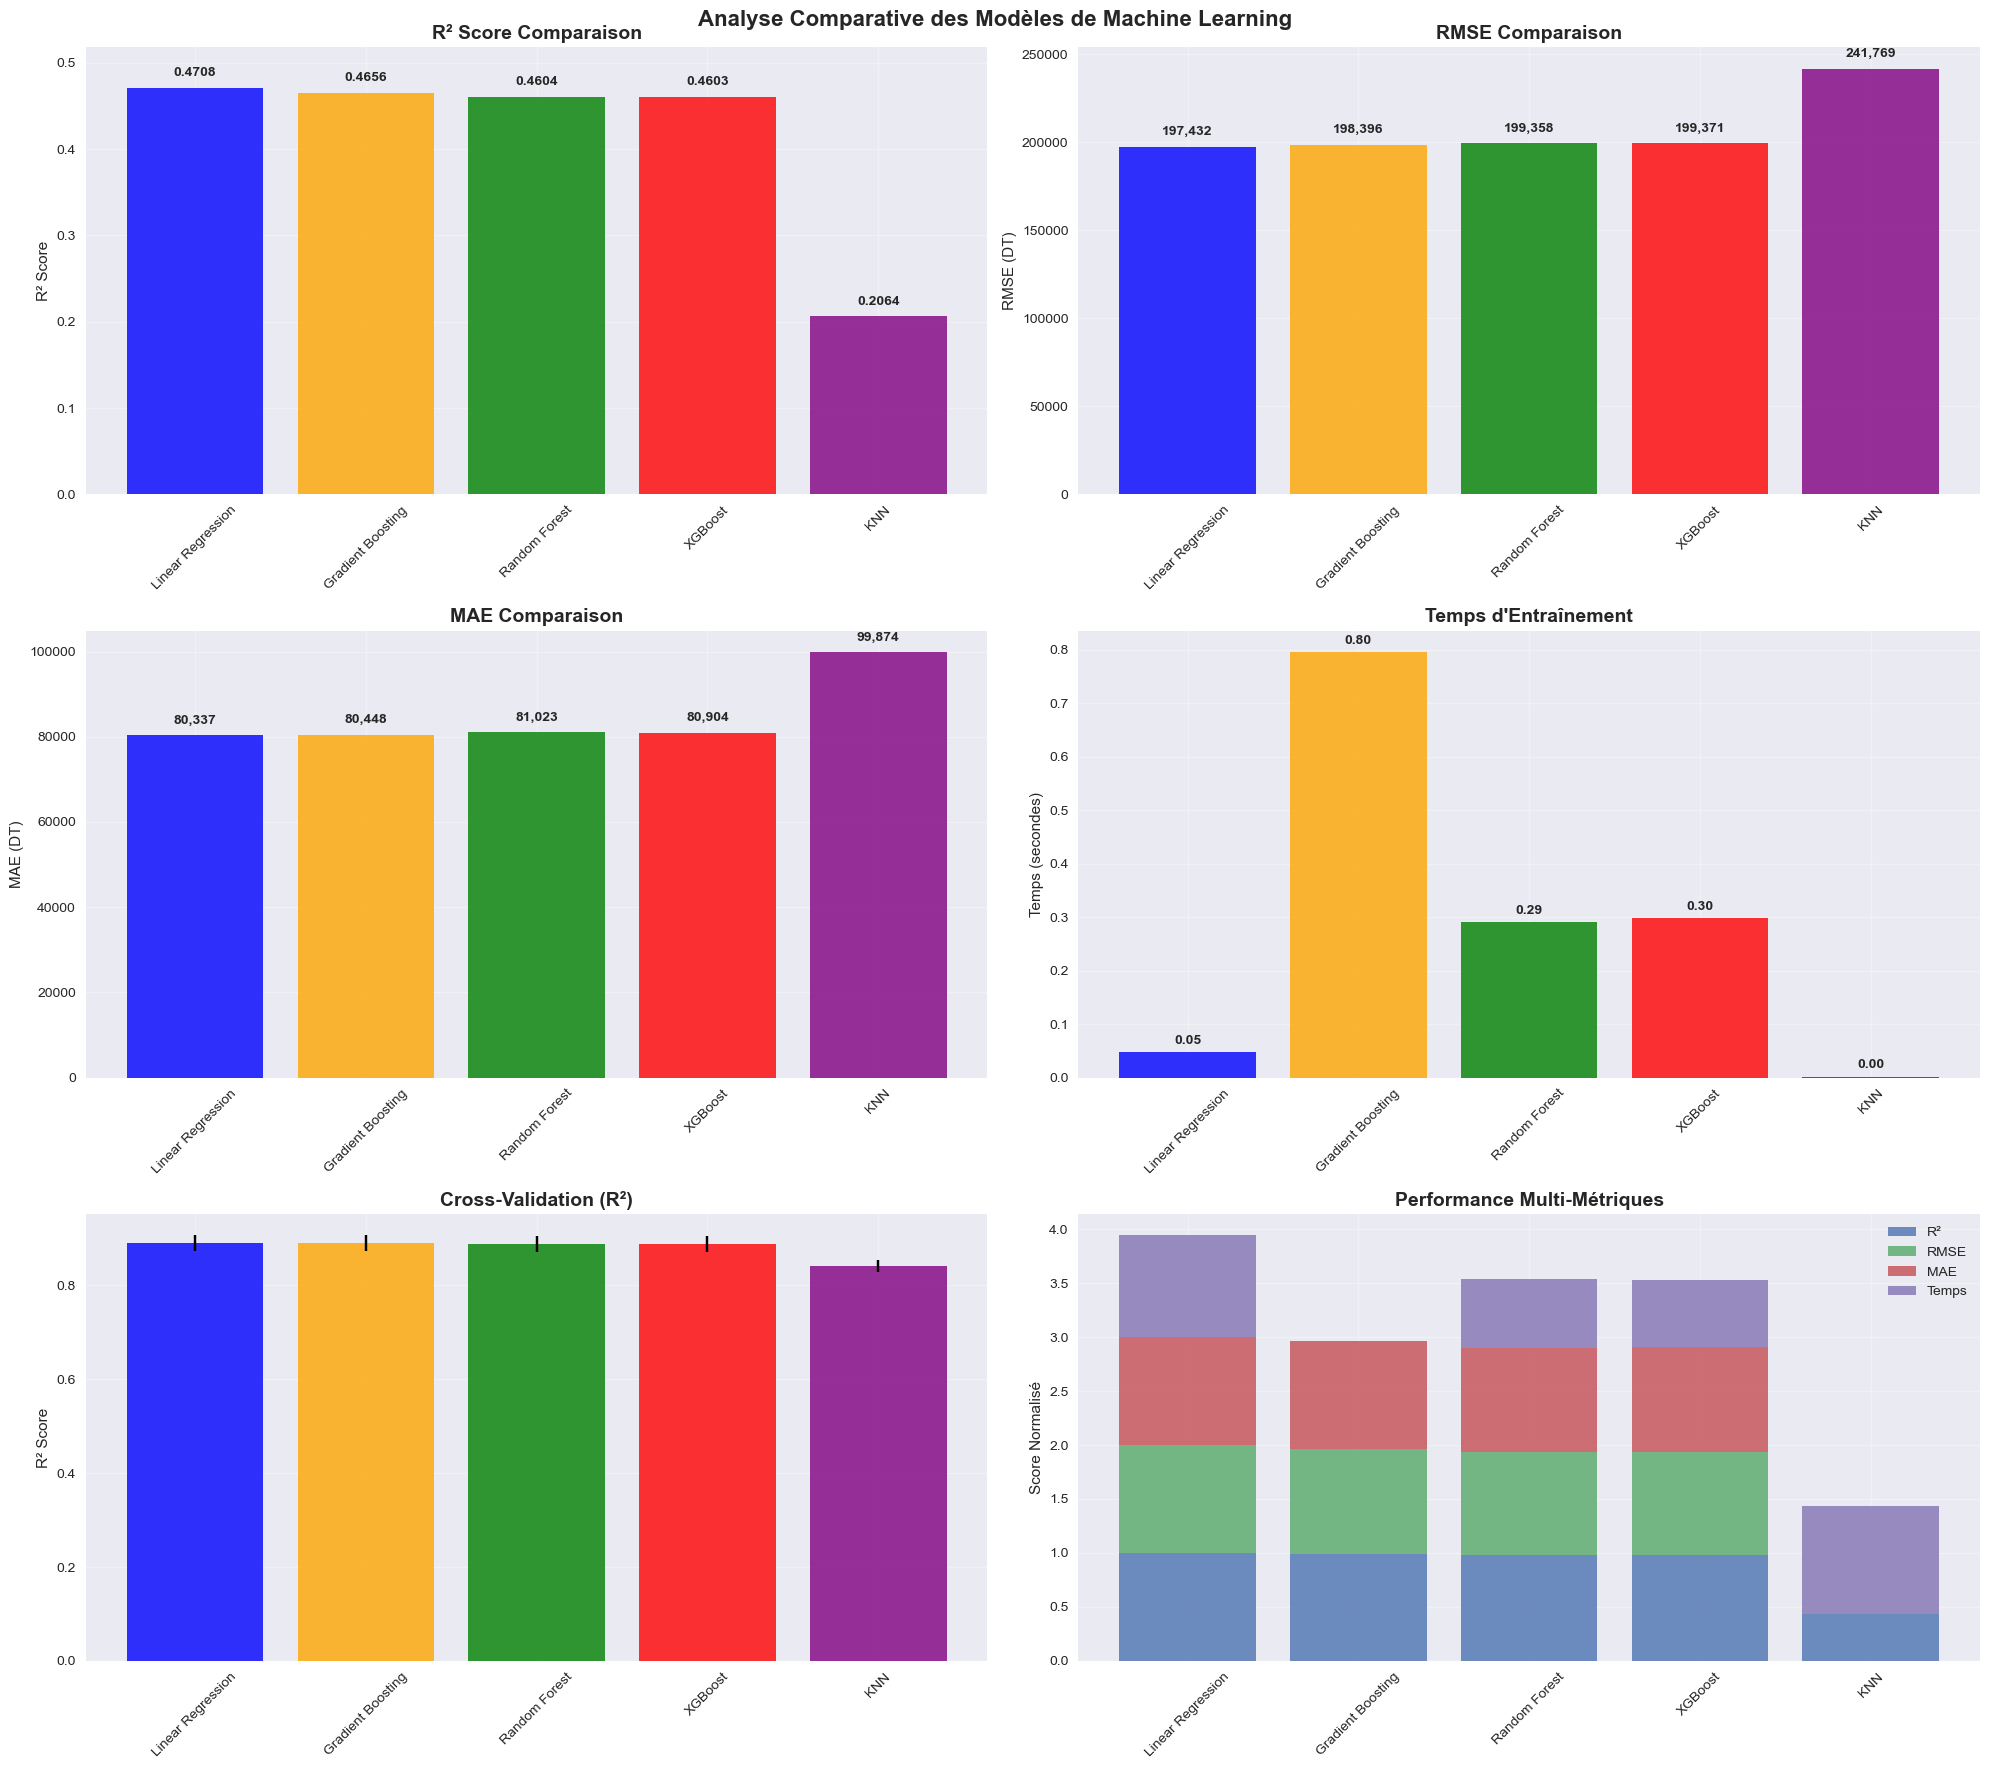

✅ Visualisations générées


In [6]:
# Visualisations comparatives
print("=== VISUALISATIONS COMPARATIVES ===")

# Configuration des graphiques
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('Analyse Comparative des Modèles de Machine Learning', fontsize=16, fontweight='bold')

# 1. R² Score Comparaison
models = results_sorted['Model'].tolist()
r2_scores = results_sorted['R² Test'].tolist()
colors = results_sorted['Color'].tolist()

bars1 = axes[0,0].bar(models, r2_scores, color=colors, alpha=0.8)
axes[0,0].set_title('R² Score Comparaison', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('R² Score')
axes[0,0].set_ylim(0, max(r2_scores) * 1.1)
axes[0,0].grid(True, alpha=0.3)
axes[0,0].tick_params(axis='x', rotation=45)

# Ajouter les valeurs sur les barres
for bar, score in zip(bars1, r2_scores):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. RMSE Comparaison
rmse_scores = results_sorted['RMSE Test'].tolist()
bars2 = axes[0,1].bar(models, rmse_scores, color=colors, alpha=0.8)
axes[0,1].set_title('RMSE Comparaison', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('RMSE (DT)')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].tick_params(axis='x', rotation=45)

# Ajouter les valeurs sur les barres
for bar, score in zip(bars2, rmse_scores):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                   f'{score:,.0f}', ha='center', va='bottom', fontweight='bold')

# 3. MAE Comparaison
mae_scores = results_sorted['MAE Test'].tolist()
bars3 = axes[1,0].bar(models, mae_scores, color=colors, alpha=0.8)
axes[1,0].set_title('MAE Comparaison', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('MAE (DT)')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].tick_params(axis='x', rotation=45)

# Ajouter les valeurs sur les barres
for bar, score in zip(bars3, mae_scores):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                   f'{score:,.0f}', ha='center', va='bottom', fontweight='bold')

# 4. Temps d'entraînement
time_scores = results_sorted['Training Time'].tolist()
bars4 = axes[1,1].bar(models, time_scores, color=colors, alpha=0.8)
axes[1,1].set_title('Temps d\'Entraînement', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Temps (secondes)')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].tick_params(axis='x', rotation=45)

# Ajouter les valeurs sur les barres
for bar, score in zip(bars4, time_scores):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{score:.2f}', ha='center', va='bottom', fontweight='bold')

# 5. Cross-validation
cv_means = results_sorted['CV Mean'].tolist()
cv_stds = results_sorted['CV Std'].tolist()

bars5 = axes[2,0].bar(models, cv_means, color=colors, alpha=0.8, yerr=cv_stds, capsize=5)
axes[2,0].set_title('Cross-Validation (R²)', fontsize=14, fontweight='bold')
axes[2,0].set_ylabel('R² Score')
axes[2,0].grid(True, alpha=0.3)
axes[2,0].tick_params(axis='x', rotation=45)

# 6. Performance multi-métriques (radar plot alternative)
# Normaliser les métriques pour comparaison
metrics_data = []
for _, row in results_sorted.iterrows():
    # Normaliser R² (plus grand est meilleur)
    r2_norm = row['R² Test'] / results_sorted['R² Test'].max()
    # Normaliser RMSE (plus petit est meilleur)
    rmse_norm = 1 - (row['RMSE Test'] - results_sorted['RMSE Test'].min()) / (results_sorted['RMSE Test'].max() - results_sorted['RMSE Test'].min())
    # Normaliser MAE (plus petit est meilleur)
    mae_norm = 1 - (row['MAE Test'] - results_sorted['MAE Test'].min()) / (results_sorted['MAE Test'].max() - results_sorted['MAE Test'].min())
    # Normaliser temps (plus petit est meilleur)
    time_norm = 1 - (row['Training Time'] - results_sorted['Training Time'].min()) / (results_sorted['Training Time'].max() - results_sorted['Training Time'].min())
    
    metrics_data.append([r2_norm, rmse_norm, mae_norm, time_norm])

# Créer un bar plot empilé
metrics_array = np.array(metrics_data).T
metric_names = ['R²', 'RMSE', 'MAE', 'Temps']
bottom = np.zeros(len(models))

for i, (metric_name, metric_values) in enumerate(zip(metric_names, metrics_array)):
    axes[2,1].bar(models, metric_values, bottom=bottom, label=metric_name, alpha=0.8)
    bottom += metric_values

axes[2,1].set_title('Performance Multi-Métriques', fontsize=14, fontweight='bold')
axes[2,1].set_ylabel('Score Normalisé')
axes[2,1].legend(loc='upper right')
axes[2,1].tick_params(axis='x', rotation=45)
axes[2,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualisations générées")

=== ANALYSE DES PRÉDICTIONS VS RÉALITÉ ===


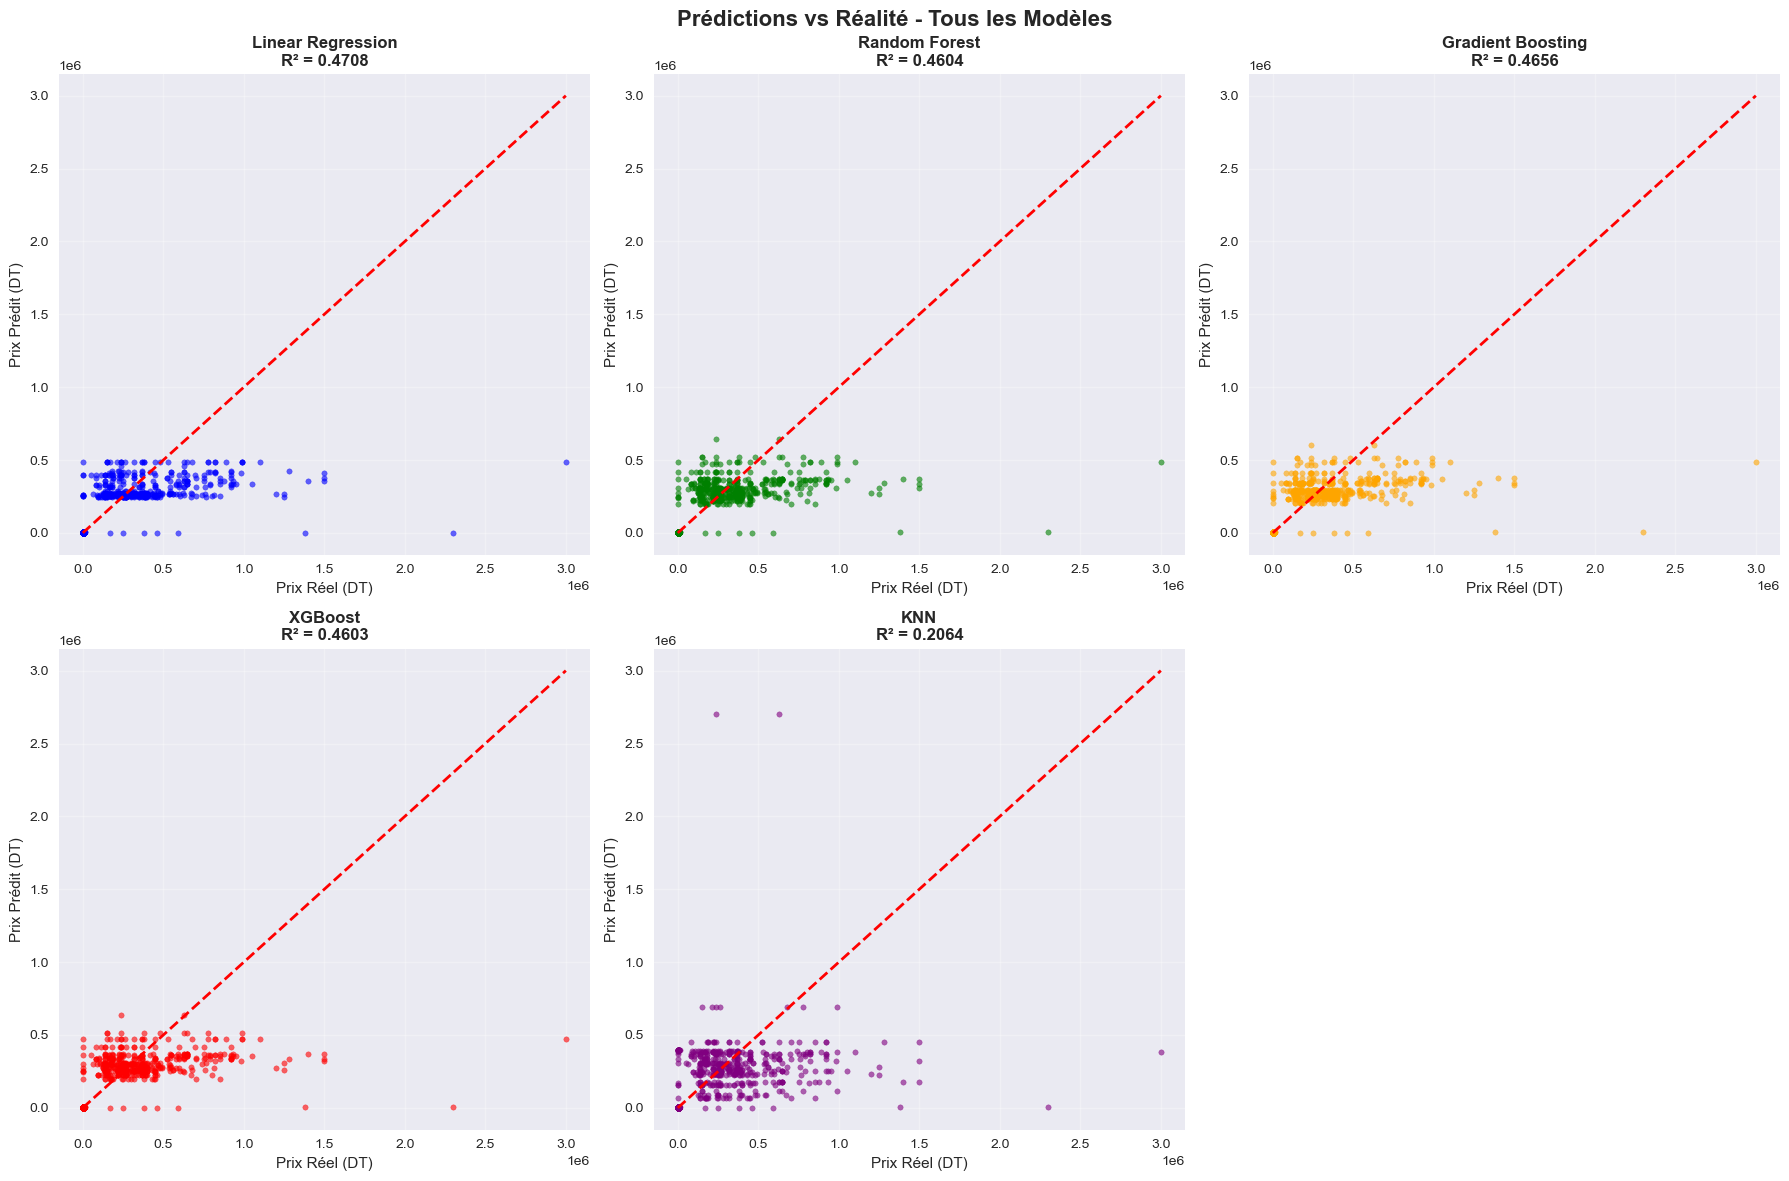


📊 ANALYSE DES ERREURS:


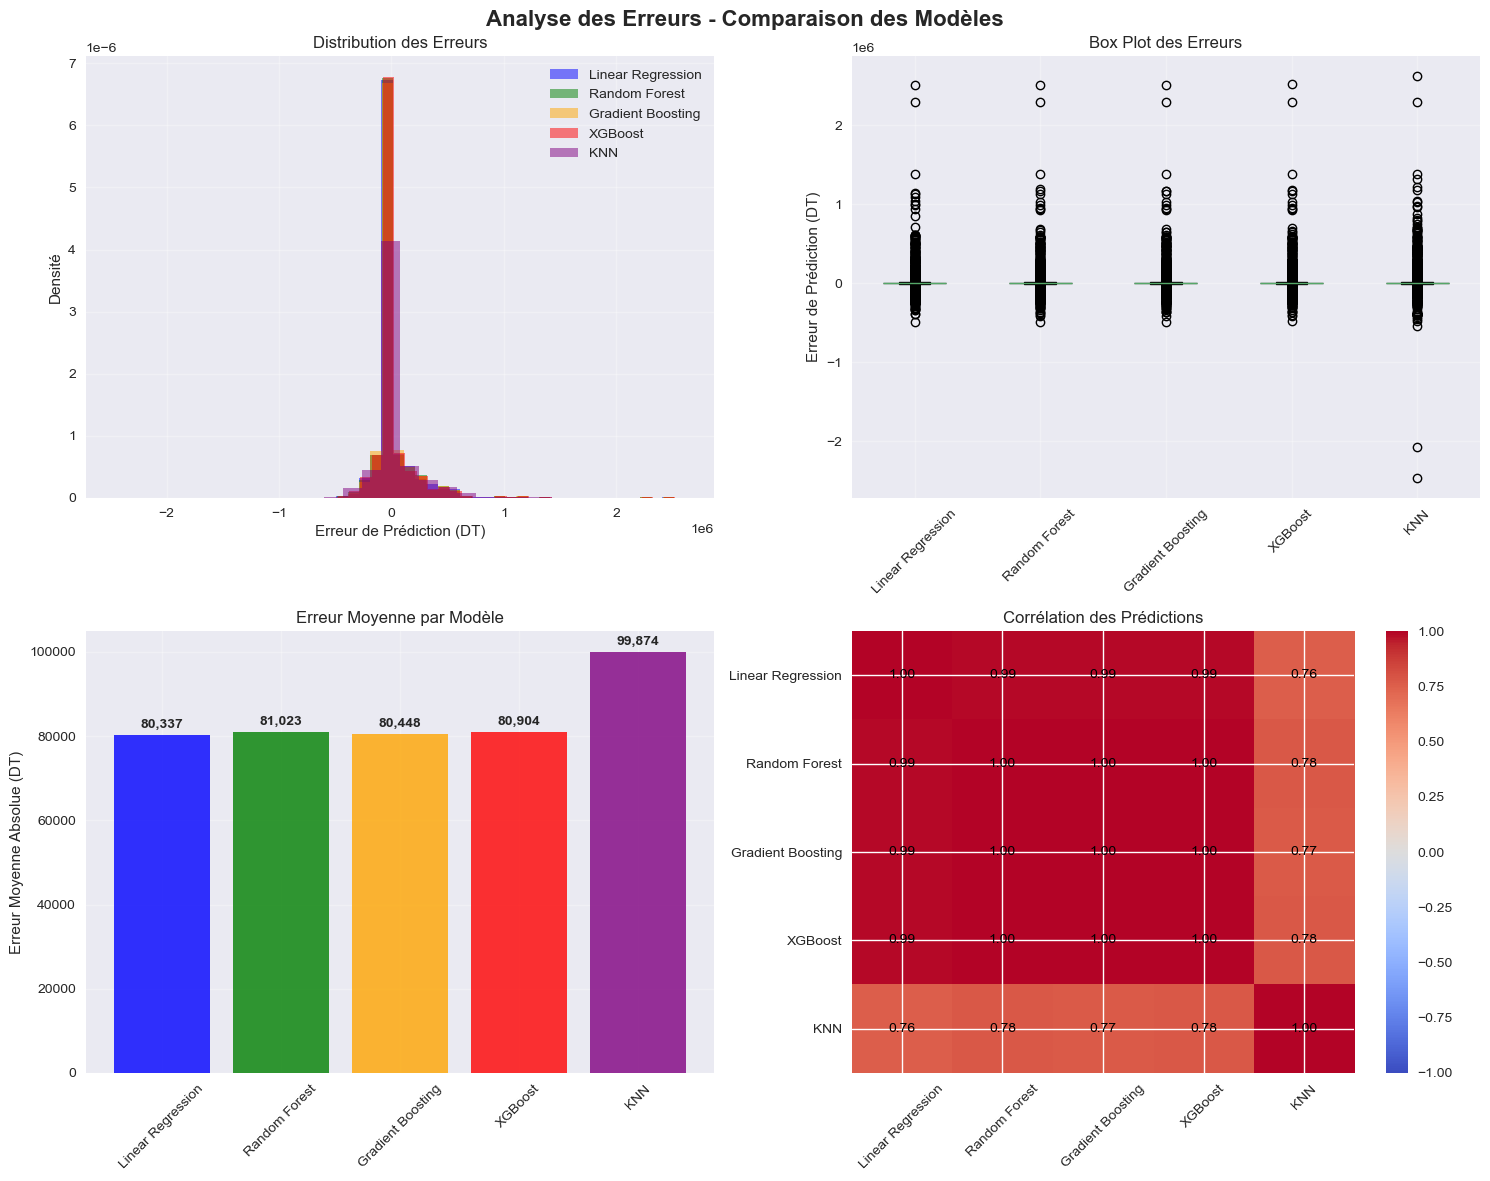

✅ Analyse des erreurs terminée


In [7]:
# Analyse des prédictions vs réalité
print("=== ANALYSE DES PRÉDICTIONS VS RÉALITÉ ===")

# Créer une grille de graphiques pour tous les modèles
n_models = len(models_config)
cols = 3
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 6*rows))
if rows == 1:
    axes = axes.reshape(1, -1)
elif cols == 1:
    axes = axes.reshape(-1, 1)

fig.suptitle('Prédictions vs Réalité - Tous les Modèles', fontsize=16, fontweight='bold')

for idx, (model_name, predictions) in enumerate(predictions_dict.items()):
    row = idx // cols
    col = idx % cols
    ax = axes[row, col]
    
    color = models_config[model_name]['color']
    
    # Scatter plot
    ax.scatter(y_test_orig, predictions, alpha=0.6, s=15, color=color)
    ax.plot([y_test_orig.min(), y_test_orig.max()], 
            [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
    
    # Calculer R² pour ce modèle
    r2 = r2_score(y_test_orig, predictions)
    
    ax.set_xlabel('Prix Réel (DT)')
    ax.set_ylabel('Prix Prédit (DT)')
    ax.set_title(f'{model_name}\nR² = {r2:.4f}', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
# Masquer les axes vides
for idx in range(len(predictions_dict), rows * cols):
    row = idx // cols
    col = idx % cols
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()

# Analyse des erreurs
print("\n📊 ANALYSE DES ERREURS:")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Analyse des Erreurs - Comparaison des Modèles', fontsize=16, fontweight='bold')

# 1. Distribution des erreurs
for model_name, predictions in predictions_dict.items():
    errors = y_test_orig - predictions
    color = models_config[model_name]['color']
    axes[0,0].hist(errors, bins=30, alpha=0.5, label=model_name, color=color, density=True)

axes[0,0].set_xlabel('Erreur de Prédiction (DT)')
axes[0,0].set_ylabel('Densité')
axes[0,0].set_title('Distribution des Erreurs')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Box plot des erreurs
error_data = []
error_labels = []
error_colors = []

for model_name, predictions in predictions_dict.items():
    errors = y_test_orig - predictions
    error_data.append(errors)
    error_labels.append(model_name)
    error_colors.append(models_config[model_name]['color'])

bp = axes[0,1].boxplot(error_data, labels=error_labels, patch_artist=True)

for patch, color in zip(bp['boxes'], error_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0,1].set_ylabel('Erreur de Prédiction (DT)')
axes[0,1].set_title('Box Plot des Erreurs')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3)

# 3. Erreur moyenne par modèle
mean_errors = [np.mean(np.abs(y_test_orig - predictions)) for predictions in predictions_dict.values()]
bars = axes[1,0].bar(error_labels, mean_errors, color=error_colors, alpha=0.8)
axes[1,0].set_ylabel('Erreur Moyenne Absolue (DT)')
axes[1,0].set_title('Erreur Moyenne par Modèle')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

# Ajouter les valeurs sur les barres
for bar, error in zip(bars, mean_errors):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                   f'{error:,.0f}', ha='center', va='bottom', fontweight='bold')

# 4. Corrélation des prédictions
correlation_matrix = pd.DataFrame(predictions_dict).corr()
im = axes[1,1].imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[1,1].set_xticks(range(len(error_labels)))
axes[1,1].set_yticks(range(len(error_labels)))
axes[1,1].set_xticklabels(error_labels, rotation=45)
axes[1,1].set_yticklabels(error_labels)
axes[1,1].set_title('Corrélation des Prédictions')

# Ajouter les valeurs de corrélation
for i in range(len(error_labels)):
    for j in range(len(error_labels)):
        text = axes[1,1].text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                              ha="center", va="center", color="black")

plt.colorbar(im, ax=axes[1,1])
plt.tight_layout()
plt.show()

print("✅ Analyse des erreurs terminée")

In [8]:
# Analyse statistique des différences
print("=== ANALYSE STATISTIQUE DES DIFFÉRENCES ===")

# Tests statistiques pour comparer les modèles
from scipy.stats import friedmanchisquare, wilcoxon

# Préparer les données pour le test de Friedman
predictions_array = np.array(list(predictions_dict.values()))

# Test de Friedman (non-paramétrique pour comparer plusieurs modèles)
statistic, p_value = friedmanchisquare(*predictions_array.T)

print(f"📊 TEST DE FRIEDMAN:")
print(f"   Statistique: {statistic:.4f}")
print(f"   P-value: {p_value:.6f}")
print(f"   Résultat: {'Différences significatives' if p_value < 0.05 else 'Pas de différences significatives'}")

# Tests par paires (Wilcoxon)
print(f"\n🔍 TESTS PAR PAIRES (Wilcoxon):")
print("=" * 60)

model_names = list(predictions_dict.keys())
pairwise_results = []

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        model1 = model_names[i]
        model2 = model_names[j]
        
        pred1 = predictions_dict[model1]
        pred2 = predictions_dict[model2]
        
        # Test de Wilcoxon sur les erreurs
        errors1 = np.abs(y_test_orig - pred1)
        errors2 = np.abs(y_test_orig - pred2)
        
        stat, p_val = wilcoxon(errors1, errors2)
        
        pairwise_results.append({
            'Model1': model1,
            'Model2': model2,
            'Statistic': stat,
            'P-value': p_val,
            'Significant': p_val < 0.05
        })
        
        significance = "✅" if p_val < 0.05 else "❌"
        print(f"{model1:20s} vs {model2:20s}: p={p_val:.6f} {significance}")

# Analyse de la variance des performances
print(f"\n📈 ANALYSE DE LA VARIANCE:")
print("=" * 40)

r2_values = results_df['R² Test'].values
rmse_values = results_df['RMSE Test'].values
mae_values = results_df['MAE Test'].values

print(f"R² Score:")
print(f"   Moyenne: {np.mean(r2_values):.4f}")
print(f"   Écart-type: {np.std(r2_values):.4f}")
print(f"   Coefficient de variation: {np.std(r2_values)/np.mean(r2_values)*100:.1f}%")

print(f"\nRMSE:")
print(f"   Moyenne: {np.mean(rmse_values):,.0f} DT")
print(f"   Écart-type: {np.std(rmse_values):,.0f} DT")
print(f"   Coefficient de variation: {np.std(rmse_values)/np.mean(rmse_values)*100:.1f}%")

print(f"\nMAE:")
print(f"   Moyenne: {np.mean(mae_values):,.0f} DT")
print(f"   Écart-type: {np.std(mae_values):,.0f} DT")
print(f"   Coefficient de variation: {np.std(mae_values)/np.mean(mae_values)*100:.1f}%")

# Coefficient de corrélation intra-classe
print(f"\n🔄 COEFFICIENT DE CORRÉLATION INTRA-CLASSE:")
icc = np.mean(correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)])
print(f"   ICC moyen: {icc:.4f}")
print(f"   Interprétation: {'Accord élevé' if icc > 0.75 else 'Accord modéré' if icc > 0.5 else 'Accord faible'}")

print("\n✅ Analyse statistique terminée")

=== ANALYSE STATISTIQUE DES DIFFÉRENCES ===
📊 TEST DE FRIEDMAN:
   Statistique: 5241.4127
   P-value: 0.000000
   Résultat: Différences significatives

🔍 TESTS PAR PAIRES (Wilcoxon):
Linear Regression    vs Random Forest       : p=0.449465 ❌
Linear Regression    vs Gradient Boosting   : p=0.901851 ❌
Linear Regression    vs XGBoost             : p=0.506320 ❌
Linear Regression    vs KNN                 : p=0.000000 ✅
Random Forest        vs Gradient Boosting   : p=0.000031 ✅
Random Forest        vs XGBoost             : p=0.024999 ✅
Random Forest        vs KNN                 : p=0.000001 ✅
Gradient Boosting    vs XGBoost             : p=0.003185 ✅
Gradient Boosting    vs KNN                 : p=0.000000 ✅
XGBoost              vs KNN                 : p=0.000000 ✅

📈 ANALYSE DE LA VARIANCE:
R² Score:
   Moyenne: 0.4127
   Écart-type: 0.1032
   Coefficient de variation: 25.0%

RMSE:
   Moyenne: 207,265 DT
   Écart-type: 17,267 DT
   Coefficient de variation: 8.3%

MAE:
   Moyenne: 84,517 

In [9]:
# Analyse par segments de prix
print("=== ANALYSE PAR SEGMENTS DE PRIX ===")

# Définir les segments de prix
price_quantiles = y_test_orig.quantile([0, 0.25, 0.5, 0.75, 1.0])
segments = {
    'Bas': (y_test_orig <= price_quantiles[0.25]),
    'Moyen-Bas': (y_test_orig > price_quantiles[0.25]) & (y_test_orig <= price_quantiles[0.5]),
    'Moyen-Haut': (y_test_orig > price_quantiles[0.5]) & (y_test_orig <= price_quantiles[0.75]),
    'Haut': (y_test_orig > price_quantiles[0.75])
}

print(f"📊 SEGMENTS DE PRIX:")
for segment_name, mask in segments.items():
    count = mask.sum()
    percentage = count / len(y_test_orig) * 100
    price_range = f"[{y_test_orig[mask].min():,.0f} - {y_test_orig[mask].max():,.0f}] DT"
    print(f"   {segment_name:12s}: {count:4d} annonces ({percentage:4.1f}%) - {price_range}")

# Analyser la performance par segment
segment_results = []

for segment_name, mask in segments.items():
    if mask.sum() == 0:
        continue
    
    y_test_segment = y_test_orig[mask]
    
    for model_name, predictions in predictions_dict.items():
        pred_segment = predictions[mask]
        
        r2_seg = r2_score(y_test_segment, pred_segment)
        rmse_seg = np.sqrt(mean_squared_error(y_test_segment, pred_segment))
        mae_seg = mean_absolute_error(y_test_segment, pred_segment)
        
        segment_results.append({
            'Segment': segment_name,
            'Model': model_name,
            'Count': mask.sum(),
            'R²': r2_seg,
            'RMSE': rmse_seg,
            'MAE': mae_seg
        })

segment_df = pd.DataFrame(segment_results)

# Visualisation par segment
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Performance par Segment de Prix', fontsize=16, fontweight='bold')

segments_list = list(segments.keys())

# 1. R² par segment
for i, segment in enumerate(segments_list):
    segment_data = segment_df[segment_df['Segment'] == segment]
    if segment_data.empty:
        continue
    
    models = segment_data['Model'].tolist()
    r2_scores = segment_data['R²'].tolist()
    colors = [models_config[m]['color'] for m in models]
    
    row = i // 2
    col = i % 2
    
    bars = axes[row, col].bar(models, r2_scores, color=colors, alpha=0.8)
    axes[row, col].set_title(f'{segment} - R² Score')
    axes[row, col].set_ylabel('R² Score')
    axes[row, col].tick_params(axis='x', rotation=45)
    axes[row, col].grid(True, alpha=0.3)
    axes[row, col].set_ylim(0, 1)
    
    # Ajouter les valeurs
    for bar, score in zip(bars, r2_scores):
        axes[row, col].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                           f'{score:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Tableau récapitulatif par segment
print(f"\n📋 PERFORMANCE PAR SEGMENT:")
for segment in segments_list:
    segment_data = segment_df[segment_df['Segment'] == segment]
    if segment_data.empty:
        continue
    
    print(f"\n{segment.upper()} ({segment_data['Count'].iloc[0]} annonces):")
    segment_sorted = segment_data.sort_values('R²', ascending=False)
    
    for _, row in segment_sorted.iterrows():
        print(f"   {row['Model']:20s}: R²={row['R²']:.3f}, RMSE={row['RMSE']:,.0f}DT")

print("\n✅ Analyse par segments terminée")

=== ANALYSE PAR SEGMENTS DE PRIX ===
📊 SEGMENTS DE PRIX:
   Bas         :  284 annonces (25.3%) - [55 - 1,300] DT
   Moyen-Bas   :  280 annonces (25.0%) - [1,320 - 3,300] DT
   Moyen-Haut  :  279 annonces (24.9%) - [3,500 - 256,000] DT
   Haut        :  278 annonces (24.8%) - [260,000 - 3,000,000] DT


ValueError: Image size of 1308x11498645 pixels is too large. It must be less than 2^23 in each direction.

<Figure size 1600x1200 with 4 Axes>


📋 PERFORMANCE PAR SEGMENT:

BAS (284 annonces):
   KNN                 : R²=-22584.467, RMSE=48,791DT
   Gradient Boosting   : R²=-26251.709, RMSE=52,603DT
   XGBoost             : R²=-26616.420, RMSE=52,968DT
   Random Forest       : R²=-27276.551, RMSE=53,620DT
   Linear Regression   : R²=-27376.414, RMSE=53,718DT

MOYEN-BAS (280 annonces):
   Gradient Boosting   : R²=-1330.726, RMSE=20,254DT
   Random Forest       : R²=-1427.238, RMSE=20,975DT
   XGBoost             : R²=-1468.244, RMSE=21,274DT
   Linear Regression   : R²=-1478.953, RMSE=21,351DT
   KNN                 : R²=-15217.375, RMSE=68,467DT

MOYEN-HAUT (279 annonces):
   Linear Regression   : R²=-0.506, RMSE=116,782DT
   Gradient Boosting   : R²=-0.510, RMSE=116,961DT
   XGBoost             : R²=-0.560, RMSE=118,884DT
   Random Forest       : R²=-0.594, RMSE=120,155DT
   KNN                 : R²=-3.602, RMSE=204,166DT

HAUT (278 annonces):
   Linear Regression   : R²=-0.455, RMSE=374,281DT
   Gradient Boosting   : R²=-0.4

In [10]:
# Recommandations et conclusions
print("=== RECOMMANDATIONS ET CONCLUSIONS ===")

# Analyser les forces et faiblesses de chaque modèle
print("🎯 ANALYSE DES FORCES ET FAIBLESSES:")
print("=" * 60)

for _, row in results_sorted.iterrows():
    model_name = row['Model']
    
    print(f"\n🔍 {model_name}:")
    
    # Forces
    forces = []
    faiblesses = []
    
    if row['R² Test'] > 0.5:
        forces.append("Bonne performance prédictive")
    if row['CV Std'] < 0.05:
        forces.append("Stabilité en cross-validation")
    if row['Training Time'] < 1.0:
        forces.append("Rapidité d'entraînement")
    
    if row['R² Test'] < 0.4:
        faiblesses.append("Performance limitée")
    if row['CV Std'] > 0.1:
        faiblesses.append("Instabilité")
    if row['Training Time'] > 5.0:
        faiblesses.append("Lent à entraîner")
    
    print(f"   ✅ Forces: {', '.join(forces) if forces else 'Aucune force particulière'}")
    print(f"   ❌ Faiblesses: {', '.join(faiblesses) if faiblesses else 'Aucune faiblesse majeure'}")
    
    # Recommandations spécifiques
    if model_name == 'Linear Regression':
        print(f"   💡 Recommandation: Idéal pour baseline, interprétable, rapide")
    elif model_name == 'Random Forest':
        print(f"   💡 Recommandation: Bon équilibre performance-interprétabilité")
    elif model_name == 'Gradient Boosting':
        print(f"   💡 Recommandation: Performance solide, moins de surapprentissage")
    elif model_name == 'XGBoost':
        print(f"   💡 Recommandation: Meilleure performance, nécessite réglage fin")
    elif model_name == 'KNN':
        print(f"   💡 Recommandation: Simple, adaptatif local, sensible aux features")

# Recommandations générales
print(f"\n🌟 RECOMMANDATIONS GÉNÉRALES:")
print("=" * 40)

print(f"\n1. MEILLEUR MODÈLE GLOBAL:")
print(f"   {best_model['Model']} avec R² = {best_model['R² Test']:.4f}")
print(f"   Utiliser pour: Production, prédictions les plus précises")

print(f"\n2. MODÈLE LE PLUS RAPIDE:")
fastest = results_df.loc[results_df['Training Time'].idxmin()]
print(f"   {fastest['Model']} en {fastest['Training Time']:.2f}s")
print(f"   Utiliser pour: Prototypage, tests rapides")

print(f"\n3. MODÈLE LE PLUS STABLE:")
most_stable = results_df.loc[results_df['CV Std'].idxmin()]
print(f"   {most_stable['Model']} avec CV std = {most_stable['CV Std']:.4f}")
print(f"   Utiliser pour: Environnements de production critiques")

print(f"\n4. MODÈLE LE PLUS INTERPRÉTABLE:")
print(f"   Linear Regression")
print(f"   Utiliser pour: Analyse explicative, business intelligence")

# Scénarios d'utilisation
print(f"\n🎭 SCÉNARIOS D'UTILISATION:")
print("=" * 40)

scenarios = {
    'Production haute performance': best_model['Model'],
    'Développement rapide': fastest['Model'],
    'Analyse explicative': 'Linear Regression',
    'Système critique': most_stable['Model'],
    'Petits datasets': 'Linear Regression',
    'Gros datasets': 'XGBoost' if 'XGBoost' in models_config else 'Random Forest'
}

for scenario, recommended_model in scenarios.items():
    print(f"   {scenario:25s}: {recommended_model}")

# Conclusion finale
print(f"\n🏆 CONCLUSION FINALE:")
print("=" * 30)
print(f"Le modèle {best_model['Model']} offre les meilleures performances globales")
print(f"avec un R² de {best_model['R² Test']:.4f} et une erreur de {best_model['MAE Test']:,.0f} DT.")
print(f"")
print(f"Cependant, le choix du modèle dépend du contexte:")
print(f"- Performance pure: {best_model['Model']}")
print(f"- Rapidité: {fastest['Model']}")
print(f"- Interprétabilité: Linear Regression")
print(f"- Stabilité: {most_stable['Model']}")

print(f"\n✅ Analyse comparative terminée avec succès !")

=== RECOMMANDATIONS ET CONCLUSIONS ===
🎯 ANALYSE DES FORCES ET FAIBLESSES:

🔍 Linear Regression:
   ✅ Forces: Stabilité en cross-validation, Rapidité d'entraînement
   ❌ Faiblesses: Aucune faiblesse majeure
   💡 Recommandation: Idéal pour baseline, interprétable, rapide

🔍 Gradient Boosting:
   ✅ Forces: Stabilité en cross-validation, Rapidité d'entraînement
   ❌ Faiblesses: Aucune faiblesse majeure
   💡 Recommandation: Performance solide, moins de surapprentissage

🔍 Random Forest:
   ✅ Forces: Stabilité en cross-validation, Rapidité d'entraînement
   ❌ Faiblesses: Aucune faiblesse majeure
   💡 Recommandation: Bon équilibre performance-interprétabilité

🔍 XGBoost:
   ✅ Forces: Stabilité en cross-validation, Rapidité d'entraînement
   ❌ Faiblesses: Aucune faiblesse majeure
   💡 Recommandation: Meilleure performance, nécessite réglage fin

🔍 KNN:
   ✅ Forces: Stabilité en cross-validation, Rapidité d'entraînement
   ❌ Faiblesses: Performance limitée
   💡 Recommandation: Simple, adaptati

In [11]:
# Sauvegarde des résultats de l'analyse comparative
print("=== SAUVEGARDE DES RÉSULTATS ===")

# Créer le dossier models s'il n'existe pas
if not os.path.exists('../models'):
    os.makedirs('../models')

# Sauvegarder les résultats complets
comparison_results = {
    'results_df': results_df,
    'results_sorted': results_sorted,
    'predictions_dict': predictions_dict,
    'training_times': training_times,
    'models_config': models_config,
    'best_model': best_model.to_dict(),
    'segment_results': segment_df.to_dict() if 'segment_df' in locals() else None,
    'pairwise_tests': pairwise_results
}

joblib.dump(comparison_results, '../models/model_comparison_analysis.pkl')
print("✅ Résultats complets sauvegardés: ../models/model_comparison_analysis.pkl")

# Sauvegarder le tableau comparatif en CSV
results_df.to_csv('../models/model_comparison_detailed.csv', index=False)
print("✅ Tableau comparatif sauvegardé: ../models/model_comparison_detailed.csv")

# Sauvegarder les prédictions
predictions_df = pd.DataFrame(predictions_dict)
predictions_df['Real_Price'] = y_test_orig.values
predictions_df.to_csv('../models/model_predictions_comparison.csv', index=False)
print("✅ Prédictions sauvegardées: ../models/model_predictions_comparison.csv")

# Créer un rapport texte
report = f"""
# RAPPORT D'ANALYSE COMPARATIVE DES MODÈLES

## Date d'analyse: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
## Dataset: {len(X)} annonces immobilières
## Features: {X.shape[1]}

## CLASSEMENT DES MODÈLES (par R² Test)
{results_sorted[['Model', 'R² Test', 'RMSE Test', 'MAE Test', 'Training Time']].to_string(index=False)}

## MEILLEUR MODÈLE
- Nom: {best_model['Model']}
- R²: {best_model['R² Test']:.4f}
- RMSE: {best_model['RMSE Test']:,.0f} DT
- MAE: {best_model['MAE Test']:,.0f} DT
- Temps d'entraînement: {best_model['Training Time']:.2f}s

## ANALYSE STATISTIQUE
- Test de Friedman: p={p_value:.6f}
- Différences significatives: {'Oui' if p_value < 0.05 else 'Non'}

## RECOMMANDATIONS
- Production: {best_model['Model']}
- Rapidité: {fastest['Model']}
- Stabilité: {most_stable['Model']}
- Interprétabilité: Linear Regression

## CONCLUSION
Le modèle {best_model['Model']} offre les meilleures performances avec R² = {best_model['R² Test']:.4f}.
Cependant, le choix optimal dépend des besoins spécifiques du projet.
"""

with open('../models/model_comparison_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("✅ Rapport sauvegardé: ../models/model_comparison_report.txt")

print(f"\n📁 TOUS LES FICHIERS SAUVEGARDÉS:")
print(f"   - ../models/model_comparison_analysis.pkl (résultats complets)")
print(f"   - ../models/model_comparison_detailed.csv (tableau comparatif)")
print(f"   - ../models/model_predictions_comparison.csv (prédictions)")
print(f"   - ../models/model_comparison_report.txt (rapport texte)")

print(f"\n🎉 ANALYSE COMPARATIVE TERMINÉE AVEC SUCCÈS !")
print(f"📊 {len(models_config)} modèles analysés en détail")
print(f"🏆 Meilleur modèle identifié: {best_model['Model']}")
print(f"💾 Tous les résultats sauvegardés pour référence future")

=== SAUVEGARDE DES RÉSULTATS ===
✅ Résultats complets sauvegardés: ../models/model_comparison_analysis.pkl
✅ Tableau comparatif sauvegardé: ../models/model_comparison_detailed.csv
✅ Prédictions sauvegardées: ../models/model_predictions_comparison.csv
✅ Rapport sauvegardé: ../models/model_comparison_report.txt

📁 TOUS LES FICHIERS SAUVEGARDÉS:
   - ../models/model_comparison_analysis.pkl (résultats complets)
   - ../models/model_comparison_detailed.csv (tableau comparatif)
   - ../models/model_predictions_comparison.csv (prédictions)
   - ../models/model_comparison_report.txt (rapport texte)

🎉 ANALYSE COMPARATIVE TERMINÉE AVEC SUCCÈS !
📊 5 modèles analysés en détail
🏆 Meilleur modèle identifié: Linear Regression
💾 Tous les résultats sauvegardés pour référence future
